In [19]:
import numpy as np
from scipy.stats import truncnorm
from scipy.integrate import quad
import pandas as pd
import matplotlib.pyplot as plt

def utility_function(gamma, tau_a, tau_b):
    a, b = 0, 1
    mu, sigma = 0.3, 0.1
    trunc_gauss = truncnorm((a - mu) / sigma, (b - mu) / sigma, loc=mu, scale=sigma)
    integrand = lambda y: ((2 + gamma) * y - 1) * trunc_gauss.pdf(y)
    result, _ = quad(integrand, tau_a, tau_b)
    return result

def get_utility_matrix(gamma_l, gamma_h, tau_l, tau_h):
    U1 = np.array([[utility_function(gamma_l, tau_l, 1)/2, 0, utility_function(gamma_l, tau_h, 1)/2, 0],
     [utility_function(gamma_l, tau_l, 1), utility_function(gamma_h, tau_l, 1)/2, utility_function(gamma_l, tau_h, 1), utility_function(gamma_h, tau_h, 1)/2],
     [utility_function(gamma_l, tau_l, tau_h) + utility_function(gamma_l, tau_h, 1)/2, utility_function(gamma_h, tau_l, tau_h), utility_function(gamma_l, tau_h, 1)/2, 0],
     [utility_function(gamma_l, tau_l, 1), utility_function(gamma_h, tau_l, tau_h) + utility_function(gamma_h, tau_h, 1)/2, utility_function(gamma_l, tau_h, 1), utility_function(gamma_h, tau_h, 1)/2]
    ])
    return U1
    
gamma_l = 0.4
gamma_h = 0.8
tau_l = 1 / (2 + gamma_h)
tau_h = 1 / (2 + gamma_l)

In [20]:
import numpy as np
from scipy.stats import truncnorm

def utility_function_sample(gamma, tau_a, tau_b, t, n_s):
    a, b = 0, 1
    mu, sigma = 0.3, 0.1
    trunc_gauss = truncnorm((a - mu) / sigma, (b - mu) / sigma, loc=mu, scale=sigma)
    samples = trunc_gauss.rvs(n_s, random_state=t)
    filtered_samples = samples[(samples >= tau_a) & (samples <= tau_b)]
    
    if len(filtered_samples) == 0:
        return 0.0  # Or np.nan 
    
    utility_values = ((2 + gamma) * filtered_samples - 1)
    return np.mean(utility_values)

def get_utility_matrix_sample(gamma_l, gamma_h, tau_l, tau_h, t, n_s):
    U1 = np.array([
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s) / 2,
            0,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            0
        ],
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s),
            utility_function_sample(gamma_h, tau_l, 1, t, n_s) / 2,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s),
            utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2
        ],
        [
            utility_function_sample(gamma_l, tau_l, tau_h, t, n_s) + utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            utility_function_sample(gamma_h, tau_l, tau_h, t, n_s),
            utility_function_sample(gamma_l, tau_h, 1, t, n_s) / 2,
            0
        ],
        [
            utility_function_sample(gamma_l, tau_l, 1, t, n_s),
            utility_function_sample(gamma_h, tau_l, tau_h, t, n_s) + utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2,
            utility_function_sample(gamma_l, tau_h, 1, t, n_s),
            utility_function_sample(gamma_h, tau_h, 1, t, n_s) / 2
        ]
    ])
    
    return U1
# utility_function_sample(0.4,0.6,0.7,1,10000)
# utility_function(0.4,0.1,0.7)

In [23]:
utility_function_sample(0.4,0.1,0.7,1,1000)
utility_function(0.4,0.1,0.7)


np.float64(-0.26364353056855616)

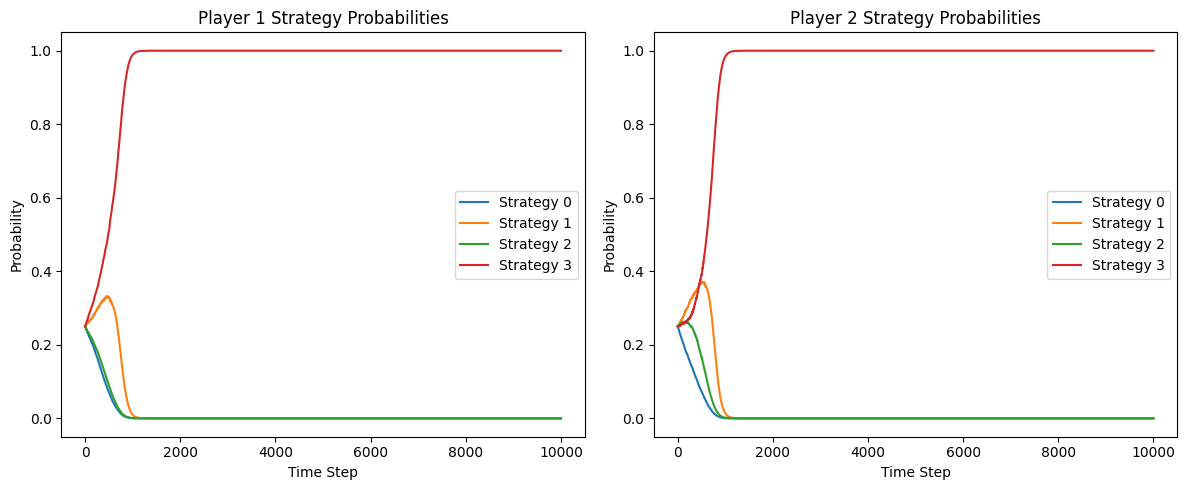

In [22]:
def exponential_weights(T, eta, num_actions, gamma_l, gamma_h, tau_l, tau_h, n_s):

    p1 = np.ones((T+1, num_actions)) / num_actions
    p2 = np.ones((T+1, num_actions)) / num_actions
    
      # Assume zero-sum game for illustration
    
    # Simulate algorithm
    for t in range(T):
        U1 = get_utility_matrix_sample(gamma_l, gamma_h, tau_l, tau_h, t, n_s)
        U2 = U1.T

        # Sample strategy
        s1 = np.random.choice(num_actions, p=p1[t])
        s2 = np.random.choice(num_actions, p=p2[t])
    
        # Compute utilities using sampled strategy of the current player
        util1 = np.array([p2[t, j]*U1[j, s1] for j in range(num_actions)])
        util2 = np.array([p1[t, j]*U2[j, s2] for j in range(num_actions)])
    
        # Update probabilities using exponential weights
        p1[t+1] = p1[t] * np.exp(eta * util1)
        p2[t+1] = p2[t] * np.exp(eta * util2)
    
        # Normalize
        p1[t+1] /= np.sum(p1[t+1])
        p2[t+1] /= np.sum(p2[t+1])
    return p1, p2

def plot_probabilities_per_player(p1, p2):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    for i in range(4):
        plt.plot(p1[:, i], label=f'Strategy {i}')
    plt.title('Player 1 Strategy Probabilities')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    for i in range(4):
        plt.plot(p2[:, i], label=f'Strategy {i}')
    plt.title('Player 2 Strategy Probabilities')
    plt.xlabel('Time Step')
    plt.ylabel('Probability')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


T = 10000  # time steps
eta = 0.1  # learning rate
num_actions = 4  # 4 strategy pairs per player
n_s = 1000
p1, p2 = exponential_weights(T, eta, num_actions,gamma_l, gamma_h, tau_l, tau_h, n_s)
plot_probabilities_per_player(p1, p2)